# WKBeam simulation setup

This notebook creates a simulation folder, generates all WKBeam config files, and
produces ready-to-run bash scripts.

**Workflow**

1. Point to the prepared data folder → `load_ec_params` reads the ECparams file, `copy_input_files` copies topfile / ne.dat / Te.dat etc. into `input/`
2. Generate the ray-tracing config — launcher geometry comes automatically from `ec_params`
3. Generate the binning configs (absorption, XZ plane, angular spectrum, …)
4. Generate `run.sh` and `plot.sh`

In [191]:
import os
import sys
import numpy as np

WKBEAM_DIR = '/home/devlamin/WanKenoBEAM'
if WKBEAM_DIR not in sys.path:
    sys.path.insert(0, WKBEAM_DIR)

from Wrapper.wrapper_aux import SimulationSetup, load_ec_params

## 1 — Simulation definition

Point to the prepared data folder, load the EC launcher parameters, create the simulation directory, and copy the input files across in one block.

In [ ]:
# --- Data source ----------------------------------------------------------
parent_folder = '/home/devlamin/WKbeam_simulations/'
data_folder   = '/home/devlamin/matlab/wkbeam_input_prep/88662_1.25'
vesselfile    = '/home/devlamin/WanKenoBEAM/Tools/PlotData/PlotVessel/88612_vessel.mat'

shot = 88662
time = 1.25
tag  = 'Fluct_Finalrun'

# --- Read EC launcher parameters (one entry per active launcher) ----------
launcher_list = load_ec_params(data_folder)

# --- Tokamak geometry (shared by binning configs) -------------------------
rmaj = 88.   # [cm]
rmin = 25.   # [cm]

# --- Create one SimulationSetup per launcher ------------------------------
sims = []
for ec_params, InputPower, launcher_name in launcher_list:
    sim_dir = f'{parent_folder}/TCV_{shot}_{time:.2f}_{tag}_{launcher_name}'
    sim = SimulationSetup(
        sim_dir    = sim_dir,
        sim_name   = launcher_name,
        rmaj       = rmaj,
        rmin       = rmin,
        InputPower = InputPower,
        tag        = tag,
    )
    sim.create_dirs()
    sim.copy_input_files(data_folder)
    sims.append((sim, ec_params))


Loaded ECparams: launcher=L4, freq=84.0 GHz, InputPower=0.882 MW
Created: /home/devlamin/EC23_WKBeam_sims/TCV_88662_1.25_Fluct_Finalrun_L4
Created: /home/devlamin/EC23_WKBeam_sims/TCV_88662_1.25_Fluct_Finalrun_L4/input
Created: /home/devlamin/EC23_WKBeam_sims/TCV_88662_1.25_Fluct_Finalrun_L4/output
Created: /home/devlamin/EC23_WKBeam_sims/TCV_88662_1.25_Fluct_Finalrun_L4/plots
Copied to /home/devlamin/EC23_WKBeam_sims/TCV_88662_1.25_Fluct_Finalrun_L4/input/: Te.dat, ne.dat, nefluct.dat, topfile


## 2 — Ray tracing config

`ec_params` (loaded above) provides all launcher geometry.  
Only specify the parameters that are *not* in the ECparams file: mode `sigma`, number of rays, and any scattering/fluctuation options.

In [193]:
for sim, ec_params in sims:
    sim.make_raytracing_config(
        sigma      = -1.,      # mode: -1 = X-mode, +1 = O-mode
        nmbrRays   = 1000,
        vesselfile = vesselfile,
        # --- optional overrides ---
        scattering              = True,
        scatteringDeltaneOverne = 'fluct_amplitude',
        scatteringLengthPerp    = 'Lperp_rhos_model',
        **ec_params,           # freq, beamwidths, curvature radii, position, angles
    )


Generating RayTracing.txt ...
  Written: /home/devlamin/EC23_WKBeam_sims/TCV_88662_1.25_Fluct_Finalrun_L4/RayTracing.txt


## 3 — Scattering models

Generate the fluctuation amplitude and perpendicular correlation length Python
files into `input/`.  After writing, `fluct_amplitude.py` is executed as a
script so you can inspect the profile before running the simulation.

## 3 — Binning configs

Each call generates one config file.  Pass only the parameters that differ from the standard defaults.

### 3a — Absorption profile (1-D in rho)

In [194]:
for sim, _ in sims:
    sim.make_absorption_config(
        nmbr        = [40],
        bin_min     = [0.01],
        bin_max     = [0.5],
        uniform_bins = True,
        # grids_file  = 'WKBacca_grids.mat',
        # grids_key   = 'rho_S',
    )


Generating Absorption.txt ...
  Written: /home/devlamin/EC23_WKBeam_sims/TCV_88662_1.25_Fluct_Finalrun_L4/Absorption.txt


### 3b — Poloidal-plane map (2-D in R, Z)

In [195]:
for sim, _ in sims:
    sim.make_xz_config(
        nmbr    = [200, 400],
        bin_min = [75., -75.],   # R range [cm]
        bin_max = [125., 75.],   # Z range [cm]
    )


Generating XZ.txt ...
  Written: /home/devlamin/EC23_WKBeam_sims/TCV_88662_1.25_Fluct_Finalrun_L4/XZ.txt


### 3c — Angular spectrum (2-D in R, phiN)

In [196]:
for sim, _ in sims:
    sim.make_angular_config(
        nmbr    = [100, 100],
        bin_min = [85., -2.],    # R [cm], phiN [-]
        bin_max = [120., -1.],
    )


Generating Angular.txt ...
  WARNING (Angular.txt): the following keys are not in the standard template and will be appended: ['equilibriumdirectory', 'rmaj', 'rmin']
  Written: /home/devlamin/EC23_WKBeam_sims/TCV_88662_1.25_Fluct_Finalrun_L4/Angular.txt


### 3d — Phase-space distribution (4-D in rho, Theta, N‖, N⊥) — optional

Uncomment to generate this config file.

In [197]:
# sim.make_rhothetaN_config(
#     nmbr        = [40, 200, 100, 100],
#     bin_min     = [0.05, -3.14159, -0.45, 0.65],
#     bin_max     = [1.0,   3.14159, -0.2,  1.0],
#     uniform_bins = False,
#     grids_file  = 'WKBacca_grids.mat',
#     grids_key   = 'rho_S',
#     # outputfilename = 'RhoThetaN_binned',   # default
# )

## 4 — Generate run and plotting scripts

`run.sh` — traces rays then bins all config files in the simulation directory.  
`plot.sh` — runs all available plotting steps in parallel.

In [198]:
n_trace = 32   # MPI ranks for ray tracing
n_bin   = 5    # MPI ranks per binning step

for sim, _ in sims:
    sim.generate_run_script(n_trace=n_trace, n_bin=n_bin)
    sim.generate_plot_script()


Run script: /home/devlamin/EC23_WKBeam_sims/TCV_88662_1.25_Fluct_Finalrun_L4/run.sh
Plot script: /home/devlamin/EC23_WKBeam_sims/TCV_88662_1.25_Fluct_Finalrun_L4/plot.sh


In [199]:
for sim, _ in sims:
    sim.make_fluct_amplitude(
        ballooning = 0.5,   # 1 = isotropic, 0 = fully ballooned
    )
    sim.make_lperp_model(
        mu      = 2.0,   # deuterium
        Z       = 1.0,
        epsilon = 0.3,   # minimum Lperp [cm]
        factor  = 7.4,   # Lperp = factor * rho_s  (GBS calibration)
    )


  Written: /home/devlamin/EC23_WKBeam_sims/TCV_88662_1.25_Fluct_Finalrun_L4/input/fluct_amplitude.py
  Written: /home/devlamin/EC23_WKBeam_sims/TCV_88662_1.25_Fluct_Finalrun_L4/input/Lperp_rhos_model.py


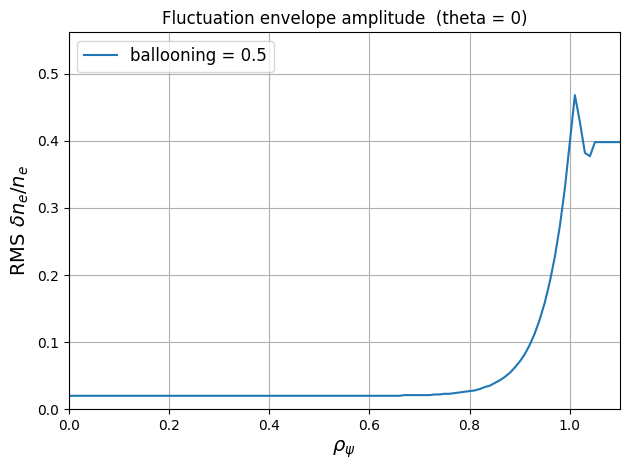

In [200]:
%matplotlib inline
import runpy

for sim, _ in sims:
    _fluct_path = os.path.join(sim.sim_dir, 'input', 'fluct_amplitude.py')
    runpy.run_path(_fluct_path, run_name='__main__')
